# Holt's Linear Model



## Giới thiệu



Ý chính của exponential smoothing (làm mịn mũ) là đặt nhiều weight (trọng số) hơn vào các observations (quan sát) gần đây và ít weight hơn, theo cấp số nhân, vào các quan sát lịch sử hơn.

Mô hình đầu tiên chúng ta giới thiệu là simple exponential smoothing. Phần 'simple' (đơn giản) đề cập đến việc mô hình không tính đến trend (xu hướng) hoặc seasonality (tính mùa vụ), và chỉ dự báo level (mức). Điều này dẫn đến mô hình cụ thể này thường mang lại các forecasts (dự báo) không đầy đủ cho hầu hết time series.

Đến với Holt's linear trend method (phương pháp xu hướng tuyến tính Holt) (còn được gọi là double exponential smoothing - làm mịn mũ kép), như tên gọi của nó, thêm một thành phần trend (xu hướng) (tuyến tính) vào mô hình simple exponential smoothing.


## Holt's Linear Trend Model


Mô hình Simple Exponential Smoothing (video trước) không có thành phần trend (xu hướng) hoặc seasonal (mùa vụ) và dẫn đến một forecast (dự báo) phẳng (tất cả các forecasts sẽ giống nhau và bằng giá trị quan sát gần đây nhất). Do đó, vào năm 1957 Charles Holt đã mở rộng mô hình này để bao gồm một thành phần trend, b_t:


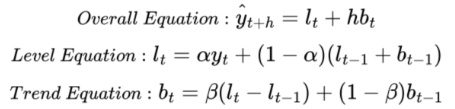

Trong đó b_t là thành phần trend được dự báo, b_{t-1} là trend được dự báo trước đó và β là trend smoothing factor (hệ số làm mịn xu hướng) có thể nhận giá trị 0 ≤ β ≤ 1.

Phương trình trend được tính từ sự thay đổi từng bước trong thành phần level (mức). Ngoài ra, từ phương trình tổng thể, thành phần trend hiện đang được nhân với time step (bước thời gian), h, do đó các forecasts không còn phẳng nữa mà là một hàm tuyến tính của h. Do đó, tên của mô hình là Holt's linear trend method (phương pháp xu hướng tuyến tính Holt).

Đối với mô hình này, chúng ta cần đặt một giá trị ban đầu cho thành phần trend, một lựa chọn phổ biến là:


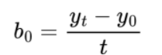

Trong đó t là một time step (bước thời gian) tùy ý trong time series. Về cơ bản đây chỉ là một average forecast model (mô hình dự báo trung bình).


Một vấn đề với công thức hiện tại này là các forecasts (dự báo) sẽ tăng hoặc giảm tùy tiện vào tương lai. Trong thực tế, không có gì phát triển cũng không suy giảm vô thời hạn. Do đó, thường có một dampening term (số hạng giảm chấn), ϕ, được thêm vào để hạn chế các forecasts ở các horizons (đường chân trời) dài:


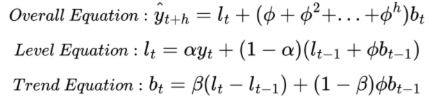

Trong đó giá trị của ϕ có thể là 0 < ϕ < 1. Lý do nó không thể là 0 hoặc 1 là để đảm bảo một số dampening (giảm chấn) thực sự xảy ra. Nếu ϕ=1 thì mô hình sẽ chỉ là Holt's linear trend method thông thường.


## Triển khai Exponential Smoothing trong Python




In [2]:
# Import các package
import plotly.graph_objects as go
import pandas as pd
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, Holt

# Đọc dữ liệu
data = pd.read_csv('AirPassengers.csv')
data['Month'] = pd.to_datetime(data['Month'])

# Chia train và test
train = data.iloc[:-int(len(data) * 0.2)]
test = data.iloc[-int(len(data) * 0.2):]


def plot_func(forecast1: list[float],
              forecast2: list[float],
              forecast3: list[float],
              title: str) -> None:
    """Hàm để vẽ các forecasts."""
    fig = go.Figure()
    fig.add_trace(go.Scatter(x=train['Month'], y=train['#Passengers'], name='Train'))
    fig.add_trace(go.Scatter(x=test['Month'], y=test['#Passengers'], name='Test'))
    fig.add_trace(go.Scatter(x=test['Month'], y=forecast1, name='Simple'))
    fig.add_trace(go.Scatter(x=test['Month'], y=forecast2, name='Holt no damp'))
    fig.add_trace(go.Scatter(x=test['Month'], y=forecast3, name='Holt'))
    fig.update_layout(template="simple_white", font=dict(size=18), title_text=title,
                      width=650, title_x=0.5, height=400, xaxis_title='Ngày',
                      yaxis_title='Khối lượng Hành khách')

    return fig.show()


# Fit mô hình simple và lấy forecasts
model_simple = SimpleExpSmoothing(train['#Passengers']).fit(optimized=True)
forecasts_simple = model_simple.forecast(len(test))

# Fit mô hình Holt và lấy forecasts
model_holt_no_damping = Holt(train['#Passengers'], damped_trend=False).fit(optimized=True)
forecasts_holt_no_damping = model_holt_no_damping.forecast(len(test))

# Fit mô hình Holt và lấy forecasts
model_holt_damping = Holt(train['#Passengers'], damped_trend=True).fit(optimized=True)
forecasts_holt_damping = model_holt_damping.forecast(len(test))

# Vẽ biểu đồ các forecasts
plot_func(forecasts_simple, forecasts_holt_no_damping, forecasts_holt_damping, "Holt's Exponential Smoothing")


Chúng ta quan sát thấy rằng Holt's method đã nắm bắt được trend (xu hướng), trong khi mô hình simple exponential smoothing chỉ là một forecast (dự báo) phẳng như chúng ta mong đợi. Tuy nhiên, vẫn còn một con voi trong phòng. Time series của chúng ta có seasonality (tính mùa vụ) khá cao và rõ ràng, mà mô hình Holt này không nắm bắt được. Tôi sẽ đi qua trong bài viết tiếp theo về cách xử lý seasonality, tuy nhiên hiện tại chúng ta có thể kết luận rằng Holt's method chỉ phù hợp cho dữ liệu không có seasonality.


In [3]:
model_holt_damping.summary()

Dep. Variable:,#Passengers,No. Observations:,116
Model:,Holt,SSE,82016.805
Optimized:,True,AIC,771.086
Trend:,Additive,BIC,784.854
Seasonal:,None,AICC,772.123
Seasonal Periods:,None,Date:,"Sun, 08 Feb 2026"
Box-Cox:,False,Time:,21:45:05
Box-Cox Coeff.:,None,,
,coeff,code,optimized
smoothing_level,1.0000000,alpha,True
smoothing_trend,0.000000,beta,True


Here the smoothing_level refers to the smoothing level parameter, α, and is very large indicating the level changes very frequently. However, the smoothing_trend, which refers to the smoothing trend parameter, β, is very low meaning the trend barely changes that much. Finally, the damping_trend, which is ϕ, is large indicating that we need to forecast a long time in the future before we can observe the increasing trend decaying.  
Ở đây smoothing_level đề cập đến tham số mức làm mịn, α, và có giá trị rất lớn cho thấy mức thay đổi rất thường xuyên. Tuy nhiên, smoothing_trend, đề cập đến tham số xu hướng làm mịn, β, có giá trị rất thấp có nghĩa là xu hướng hầu như không thay đổi nhiều. Cuối cùng, damping_trend, tức là ϕ, có giá trị lớn cho thấy chúng ta cần dự báo một khoảng thời gian dài trong tương lai trước khi có thể quan sát thấy xu hướng tăng đang suy giảm.


